#  Heart Disease Prediction

## Objective
Predict whether a person has heart disease using medical attributes.

## Dataset
Heart Disease UCI Dataset (Kaggle)

## Steps
1. Load dataset
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. Train classification model
5. Evaluate model
6. Feature importance
7. Conclusion

Upload & Load Dataset

In [ ]:
# Import libraries
import pandas as pd
import numpy as np

# Load dataset
data = pd.read_csv("heart.csv")

# Show first 5 rows
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Basic Data Inspection

In [ ]:
# Check dataset shape
data.shape


(1025, 14)

In [ ]:
# Column names
data.columns


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
# Dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
# Statistical summary
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Data Cleaning

In [ ]:
# Check for missing values
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Exploratory Data Analysis (EDA)

Heart Disease Distribution

/tmp/ipython-input-3651696463.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


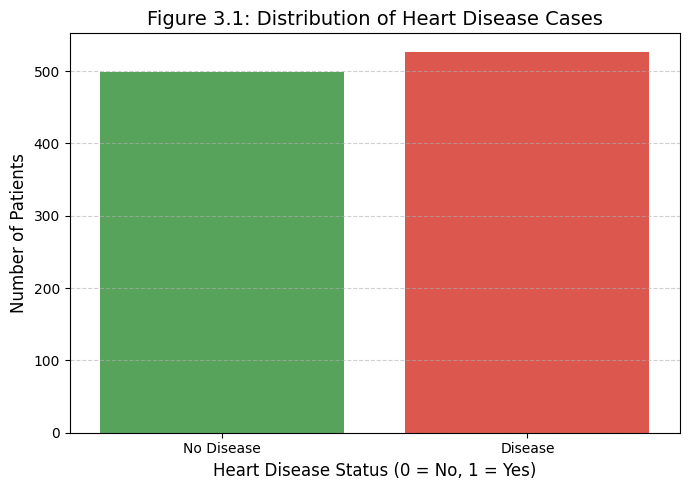

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='target',
    data=data,
    palette=['#4CAF50', '#F44336']
)

plt.title("Figure 3.1: Distribution of Heart Disease Cases", fontsize=14)
plt.xlabel("Heart Disease Status (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

plt.xticks([0,1], ['No Disease', 'Disease'])
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Prepare Features & Target

In [ ]:
# Features (all except target)
X = data.drop('target', axis=1)

# Target variable
y = data['target']

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split


# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Classification Model

In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

# Initialize model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

Model Evaluation

In [ ]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 2))

Accuracy: 0.8


Confusion Matrix

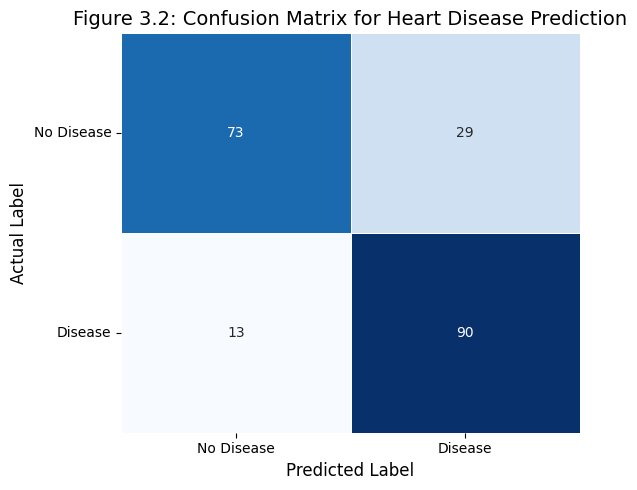

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5
)

plt.title("Figure 3.2: Confusion Matrix for Heart Disease Prediction", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)

plt.xticks([0.5, 1.5], ['No Disease', 'Disease'])
plt.yticks([0.5, 1.5], ['No Disease', 'Disease'], rotation=0)

plt.tight_layout()
plt.show()

ROC Curve

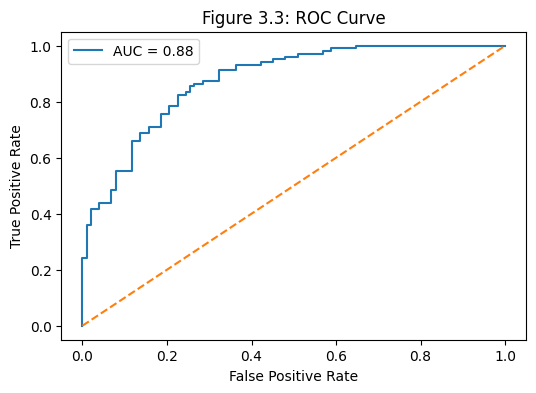

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC values
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc, 2)))
plt.plot([0,1], [0,1], '--')

plt.title("Figure 3.3: ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Feature Importance

In [ ]:
# Create feature importance from Logistic Regression coefficients
importance = pd.Series(
    model.coef_[0],
    index=X.columns
)

# Sort by importance value
importance = importance.sort_values(ascending=False)

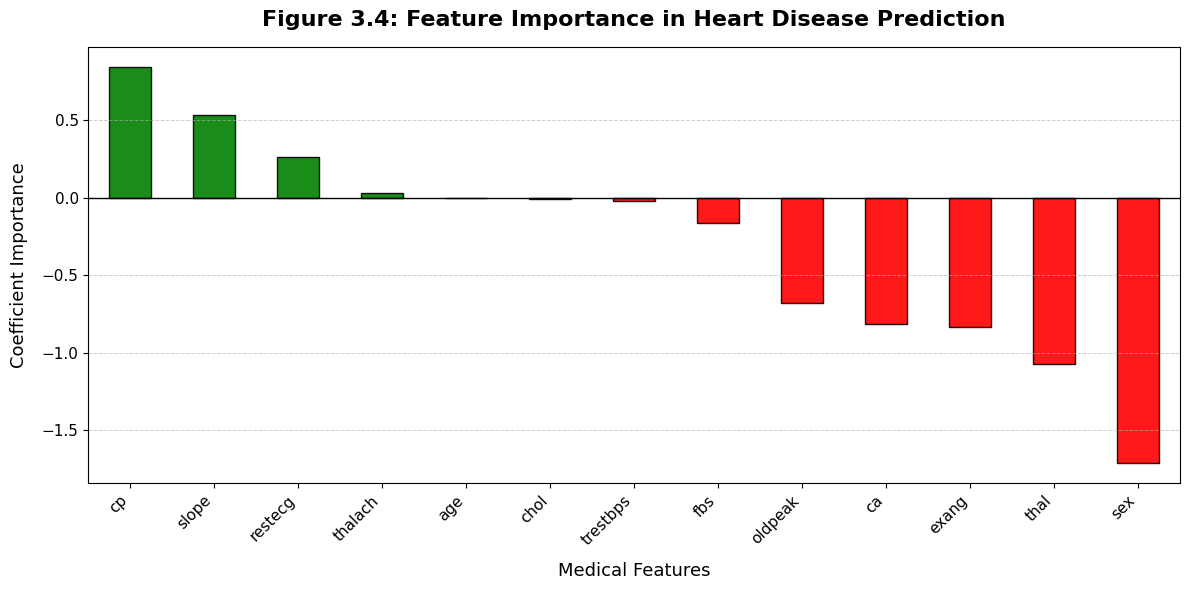

In [ ]:
plt.figure(figsize=(12, 6))

# Assign colors based on positive or negative values
colors = ['green' if val > 0 else 'red' for val in importance.values]

importance.plot(
    kind='bar',
    color=colors,
    edgecolor='black',
    alpha=0.9
)

plt.title(
    "Figure 3.4: Feature Importance in Heart Disease Prediction",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    "Medical Features",
    fontsize=13,
    labelpad=10
)

plt.ylabel(
    "Coefficient Importance",
    fontsize=13,
    labelpad=10
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=11
)

plt.yticks(fontsize=11)

# Horizontal reference line at zero
plt.axhline(0, color='black', linewidth=1)

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.7,
    alpha=0.6
)

plt.tight_layout()
plt.show()

# Conclusion

- A Logistic Regression model was trained to predict heart disease.
- The model achieved good accuracy and ROC-AUC score.
- Features like chest pain, maximum heart rate, and cholesterol were important.
- This model can help in early detection of heart disease.